<a href="https://colab.research.google.com/github/chamela-yohan/Agentic-AI-Step-by-Step/blob/main/Agentic_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install langgraph -q

# Stage 1
## Simple Graph (with edges and nodes)

In [ ]:
from typing import TypedDict # For keys initiazlie

In [ ]:
class AgentState(TypedDict):
  name: str
  age: int
  message: str


In [ ]:
def hello_name(state: AgentState)-> AgentState:
  state['message'] = f"Hello {state['name']}!"
  return state

def hello_age(state: AgentState)-> AgentState:
  state['message'] = f"{state['message']} Your age is: {state['age']}"
  return state

In [ ]:
from langgraph.graph import StateGraph, START, END

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("hello_name", hello_name)
workflow.add_node("hello_age", hello_age)

workflow.add_edge(START, "hello_name")
workflow.add_edge("hello_name", "hello_age")
workflow.add_edge("hello_age", END)

app = workflow.compile()

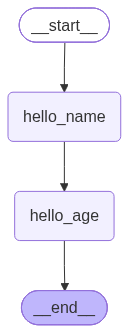

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke({"name": "Kasun", "age": 27})
print(result["message"])

Hello Kasun! Your age is: 27


### Conditional Graph

In [ ]:
class ConditionAgentState(TypedDict):
  num1: int
  num2: int
  operation: str
  result: int

In [ ]:
def addition(state: ConditionAgentState)-> ConditionAgentState:
  state["result"] = state["num1"] + state["num2"]
  return state

def substract(state: ConditionAgentState)-> ConditionAgentState:
  state["result"] = state["num1"] - state["num2"]
  return state

def multiply(state: ConditionAgentState)-> ConditionAgentState:
  state["result"] = state["num1"] * state["num2"]
  return

def divide(state: ConditionAgentState)-> ConditionAgentState:
  state["result"] = state["num1"] / state["num2"]
  return state

# Decistion node
def decision_node(state: ConditionAgentState)-> ConditionAgentState:
  if state["operation"] == "+":
    return "addition_operation"
  elif state["operation"] == "-":
    return "subtraction_operation"
  elif state["operation"] == "*":
    return "multiplication_operation"
  elif state["operation"] == "/":
    return "division_operation"
  else:
    return "invalid_operation"

In [ ]:
condition_workflow = StateGraph(ConditionAgentState)

condition_workflow.add_node("addition", addition)
condition_workflow.add_node("subtraction", substract)
condition_workflow.add_node("multiplication", multiply)
condition_workflow.add_node("division", divide)
condition_workflow.add_node("router", lambda state: state)

condition_workflow.add_edge(START, "router")
condition_workflow.add_conditional_edges(
    "router",
    decision_node,
    {
        "addition_operation": "addition",
        "subtraction_operation": "subtraction",
        "multiplication_operation": "multiplication",
        "division_operation": "division",
    }
)
condition_workflow.add_edge("addition", END)
condition_workflow.add_edge("subtraction", END)
condition_workflow.add_edge("multiplication", END)
condition_workflow.add_edge("division", END)



app = condition_workflow.compile()


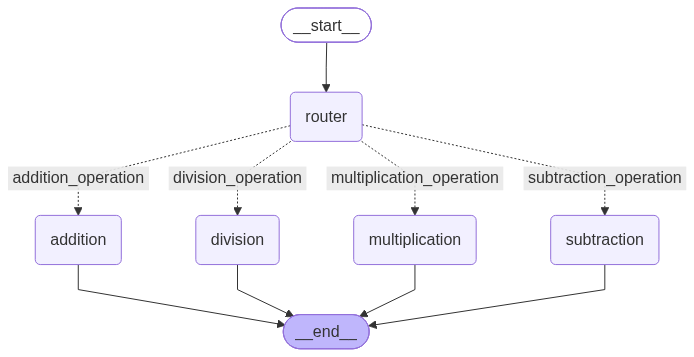

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
result = app.invoke({"num1": 10, "num2": 20, "operation": "/"})
result["result"]

0.5

# STATGE 2
## With LLM

In [ ]:
#!pip install langchain -q
#!pip install langchain-openai -q

In [ ]:
from typing import List, Union
from langchain_core.messages import HumanMessage, AIMessage

In [ ]:
class AgentState(TypedDict):
  messages: List[Union[HumanMessage, AIMessage]]

In [ ]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('API_KEY')

In [ ]:
#from langchain_openai import ChatOpenAI

#llm = ChatOpenAI(
#    model = "gpt-3.5-turbo",
#    temperature = 0.0,
#)

In [ ]:
def chatbot(state: AgentState)-> AgentState:
 response = llm.invoke(state["messages"])
 print(f"\nAI: {response.content}")
 return state

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("chatbot", chatbot)

workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

app = workflow.compile()

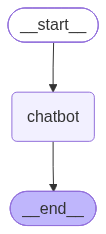

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
#user_input = input("Enter a Query: ")
#result = app.invoke({"messages": [HumanMessage(content=user_input)]})
#print(result)

In [ ]:
!pip install -U langchain-google-genai

## Try With GEMINI

In [ ]:
!pip install langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 13.6 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstalled google-genai-2.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [42]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from google.colab import userdata

from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END

from typing import TypedDict,List,Union

In [44]:
os.environ["GOOGLE_API_KEY"] = userdata.get('GEMINI_API_KEY')

In [45]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.7-flash"
)

In [ ]:
class AgentState(TypedDict):
  messages: List[Union[HumanMessage, AIMessage]]

In [ ]:
def geminiBot(state: AgentState)-> AgentState:
 response = llm.invoke(state["messages"])
 state["messages"].append(AIMessage(content=response.content))
 print(f"\nAI: {response.content}")
 return state

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("geminibot", geminiBot)

workflow.add_edge(START, "geminibot")
workflow.add_edge("geminibot", END)

app = workflow.compile()

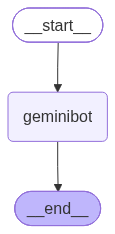

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
history = []

user_input = input("Enter a Query: ")
while user_input != "exit":
  history.append(HumanMessage(content=user_input))
  result = app.invoke({"messages": history})
  history=result["messages"]
  user_input = input("Enter a Query: ")

Enter a Query: exit


# Stage 3
## Agent + Use Tools

In [4]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

import os
from google.colab import userdata

In [48]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages]

In [ ]:
os.environ["GOOGLE_API_KEY"] = userdata.get('GEMINI_API_KEY')

llm = ChatGoogleGenerativeAI(
    model="gemini-3.7-flash"
)

In [ ]:
@tool
def addition(a: int, b: int):
  """This is the addition function that adds 2 numbers"""
  return a + b

@tool
def subtraction(a: int, b: int):
  """This is the subtraction function that subtract 2 number"""
  return a - b

@tool
def multiplication(a: int, b: int):
  """This is the multiplication function that multiply 2 numbers"""
  return a * b

@tool
def devision(a: int, b: int):
  """This is the devision function that divide 2 numbers"""
  return a / b

In [ ]:
tools = [addition, subtraction, multiplication, devision]


In [ ]:
llm_with_tools = llm.bind_tools(tools)

In [ ]:
def llm_call(state: AgentState)->AgentState:
  system_prompt = SystemMessage(
      content="You are an intelligent AI assistant, please answer my query."
  )
  response = llm_with_tools.invoke([system_prompt] + state["messages"])
  return {"messages": [response]}

In [ ]:
def decision_node(state: AgentState):
  messages = state["messages"]
  last_message = messages[-1]
  if not last_message.tool_calls:
    return "end"
  else:
    return "continue"

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("agent", llm_call)

tool_node = ToolNode(tools=tools)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    decision_node,
    {
        "continue": "tools",
        "end": END,
    }

)

workflow.add_edge("tools", "agent")

app = workflow.compile()

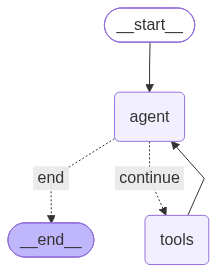

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
def print_stream(stream):
  for s in stream:
    message = s["messages"][-1]
    if isinstance(message, tuple):
      print(message)
    else:
      message.pretty_print()

In [ ]:
inputs = {"messages": [("user", "Add 40 and 12, and then multiply by 2")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 40 and 12, and then multiply by 2
================================== Ai Message ==================================

[]
Tool Calls:
  addition (call_1429486)
 Call ID: call_1429486
  Args:
    a: 40
    b: 12
================================= Tool Message =================================
Name: addition

52
================================== Ai Message ==================================

[]
Tool Calls:
  multiplication (call_2648306)
 Call ID: call_2648306
  Args:
    b: 2
    a: 52
================================= Tool Message =================================
Name: multiplication

104
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The result of adding 40 and 12, and then multiplying by 2 is **104**.\n\n**Calculation Steps:**\n1. $40 + 12 = 52$\n2. $52 \\times 2 = 104$', 'extras': {'signature': 'EqwBCqkBARFNMg98jbD6yosMLTIIHHMNwBDoIkRJ1+AK

In [38]:
!pip install duckduckgo-search -q
!pip install pyowm -q
!pip install langchain_community -q
!pip install mypy_extensions -q
!pip install -U duckduckgo-search langchain-community -q
!pip install -U ddgs -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 42.1 MB/s eta 0:00:00


## Introduce whether and search capabilities

In [36]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import OpenWeatherMapAPIWrapper
from langchain_community.agent_toolkits.load_tools import load_tools

In [26]:
os.environ["OPENWEATHERMAP_API_KEY"] = userdata.get("WHETHER_API")

In [39]:
# Initialize DuckDuckGo Search tool
search_tool = DuckDuckGoSearchRun()

# Initialize OpenWeatherMap tool
weather = OpenWeatherMapAPIWrapper()

weather_tool = load_tools(["openweathermap-api"])[0]

In [40]:
tools = [search_tool, weather_tool]

In [46]:
llm_with_tools = llm.bind_tools(tools=tools)

In [49]:
def llm_call(state: AgentState)-> AgentState:
  system_prompt = SystemMessage(
    content="You are an intelligent AI assistant, please answer my query."
  )
  response = llm_with_tools.invoke([system_prompt] + state["messages"])
  state["messages"].append(response)
  return state

In [50]:
def decision_node(state: AgentState):
  messages = state["messages"]
  last_message = messages[-1]
  if not last_message.tool_calls:
    return "end"
  else:
    return "continue"

In [51]:
workflow = StateGraph(AgentState)


workflow.add_node("agent", llm_call)

tool_node = ToolNode(tools=tools)
workflow.add_node("tools",tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    decision_node,
    {
        "continue": "tools",
        "end": END
    }
)

workflow.add_edge("tools", "agent")

app = workflow.compile()


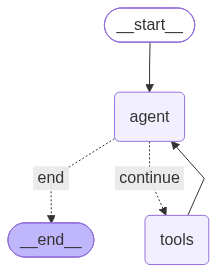

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [52]:
def print_stream(stream):
  for s in stream:
    message = s["messages"][-1]
    if isinstance(message, tuple):
      print(message)
    else:
      message.pretty_print()

In [54]:
inputs = {"messages": [("user", "What is the current whether in kandy")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What is the current whether in kandy
================================== Ai Message ==================================

[]
Tool Calls:
  open_weather_map (call_3781996)
 Call ID: call_3781996
  Args:
    location: Kandy,LK
================================= Tool Message =================================
Name: open_weather_map

In Kandy,LK, the current weather is as follows:
Detailed status: moderate rain
Wind speed: 1.96 m/s, direction: 307°
Humidity: 71%
Temperature: 
  - Current: 27.32°C
  - High: 27.32°C
  - Low: 27.32°C
  - Feels like: 29.51°C
Rain: {'1h': 1.46}
Heat index: None
Cloud cover: 78%
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The current weather in **Kandy, Sri Lanka** is:\n\n* **Condition:** Moderate rain (Cloud cover: ~78%)\n* **Temperature:** 27.3°C (Feels like 29.5°C)\n* **Humidity:** 71%\n* **Wind:** ~2.0 m/s (Light breez

# Step 4
## Agent with RAG

In [71]:
!pip install -U --force-reinstall \
    "chromadb" \
    "langchain-chroma" \
    "opentelemetry-api" \
    "opentelemetry-sdk" \
    "opentelemetry-proto" \
    "opentelemetry-exporter-otlp-proto-grpc"


  Using cached chromadb-1.5.9-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.0 kB)
  Using cached langchain_chroma-1.1.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached opentelemetry_api-1.44.0-py3-none-any.whl.metadata (1.4 kB)
  Using cached opentelemetry_sdk-1.44.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached opentelemetry_proto-1.44.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached opentelemetry_exporter_otlp_proto_grpc-1.44.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached build-1.6.1-py3-none-any.whl.metadata (5.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 2.5 MB/s eta 0:00:00
  Using cached pydantic_settings-2.15.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached pybase64-1.5.0-cp313-cp313-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (11 kB)
  Using cached onnxruntime-1.30.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.7 kB)
  Using cached pypika-0.51.1-py2.py3-none-any.

In [69]:
!pip install -qU langchain-chroma

In [9]:
!pip install pypdf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 5.6 MB/s eta 0:00:00


In [26]:
import os
from typing import Annotated, Sequence, TypedDict

# LangGraph core workflow imports
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

# LangChain message models
from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)

from langchain_core.tools import tool

# Google Gemini model wrappers
from langchain_google_genai import (
    ChatGoogleGenerativeAI,
    GoogleGenerativeAIEmbeddings,
)


# Text extraction, chunking, and vector storage
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [4]:
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get('GEMINI_API_KEY')

llm = ChatGoogleGenerativeAI(
    model="gemini-3.7-flash"
)

In [17]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-2"
)

In [7]:
pdf_loader = PyPDFLoader("/content/About_Chamela_Aththanayaka.pdf")

In [10]:
pages = pdf_loader.load()

In [11]:
pages

[Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-09-14T10:50:05+00:00', 'author': 'Chamela Aththanayaka', 'keywords': '', 'moddate': '2026-09-14T10:50:05+00:00', 'subject': '(unspecified)', 'title': 'About Chamela Aththanayaka', 'trapped': '/False', 'source': '/content/About_Chamela_Aththanayaka.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content="About Chamela Aththanayaka\nSoftware engineer, lecturer, and graduate-school applicant — Negombo, Sri Lanka\nProfile\nChamela Aththanayaka is a Software Engineering graduate (BEng Hons) based in Sri Lanka, in the\nNegombo area, with connections to Kandy. Chamela works as a Lecturer at the Java Institute for\nAdvanced Technology. A personal portfolio site, styled with a Need for Speed: Most Wanted\naesthetic, is hosted at chamela-yohan.vercel.app and showcases projects split into Software\nEngineering and Machine Learning / Data Science tabs, with a Resend

In [20]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
)

In [21]:
pages_split = text_splitter.split_documents(pages)

In [22]:
len(pages_split)

7

In [18]:
vectorstore = Chroma.from_documents(
    documents=pages_split,
    embedding=embeddings,
    persist_directory="./vectorstore",
    collection_name="data"
)

In [23]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

In [52]:
@tool
def retriever_tool(query: str) -> str:
    """
    This tool searches and returns the information Chamela Aththanayaka.
    """
    docs = retriever.invoke(query)
    if not docs:
        return "I found no relevant information"
    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i+1}:\n{doc.page_content}")

    return "\n\n".join(results)


In [53]:
tools = [retriever_tool]
llm_with_tools = llm.bind_tools(tools)

In [54]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages]

In [55]:
def should_continue(state: AgentState):
  """Check if the last message contains tool calls."""
  result = state["messages"][-1]
  return hasattr(result,'tool_calls') and len(result.tool_calls) > 0

In [56]:
system_prompt = """
You are an intelligent AI assistant who answers questions about codeprolk based on the PDF document loaded into your knowledge base.
Use the retriever tool available to answer questions about the given data. You can make multiple calls if needed.
If you need to look up some information before asking a follow up question, you are allowed to do that!
Please always cite the specific parts of the documents you use in your answers.
"""

In [57]:
tools_dict = {tool.name: tool for tool in tools}

In [58]:
tools_dict

{'retriever_tool': StructuredTool(name='retriever_tool', description='This tool searches and returns the information Chamela Aththanayaka.', args_schema=<class 'langchain_core.utils.pydantic.retriever_tool'>, func=<function retriever_tool at 0x7b50c297cea0>)}

In [59]:
# LLM Agent
def call_llm(state: AgentState) -> AgentState:
    """Function to call the LLM with the current state."""
    messages = list(state['messages'])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm_with_tools.invoke(messages)
    print(message)
    return {'messages': [message]}

In [60]:
# Retriever Agent
def take_action(state: AgentState) -> AgentState:
    """Execute tool calls from the LLM's response."""

    tool_calls = state['messages'][-1].tool_calls
    results = []
    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}")

        if not t['name'] in tools_dict: # Checks if a valid tool is present
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."

        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")


        # Appends the Tool Message
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {'messages': results}

In [61]:
workflow = StateGraph(AgentState)

workflow.add_node("llm", call_llm)
workflow.add_node("retriever_agent", take_action)

workflow.add_edge(START, "llm")
workflow.add_conditional_edges(
    "llm",
    should_continue,
    {True: "retriever_agent", False: END}
)
workflow.add_edge("retriever_agent", "llm")

app = workflow.compile()

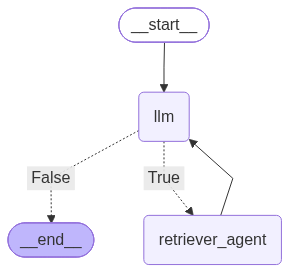

In [62]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [63]:

result = app.invoke({"messages": [HumanMessage(content="Who is Chamela")]})

content=[] additional_kwargs={'function_call': {'name': 'retriever_tool', 'arguments': '{"query": "Who is Chamela Aththanayaka"}'}, '__gemini_function_call_thought_signatures__': {'call_3701127': 'EuEBCt4BARFNMg8A+pCrNet6e3pGfbgRhpA6fcg4lV7khlELL4pTRTFS7JlcqgHFipJU2hZ+PKlzvN3DI7HNTjC6rPH50thGlgI4ysyNWzdSDi9LlCP8wrSLe/uvtDPN4X1KgpT6K+79SJq+U7nRFGG5CeX4O/7RJIm6qk5kLsH1fCzXo31YHSaxXXLHHKWqyD3BUzQuj808BChlJ93cNh4Zr6vnLyI/8SaesFGqgG4Y1ZaNpBHYAwKoHLdSf0f/bLBUYIBXbYDSnMpdUZua4li+fT/TELtWUY3scFS6lY/6c0pa'}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.7-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--01a09ff0-cdf9-7101-8114-7ba8127dfdfc-0' tool_calls=[{'name': 'retriever_tool', 'args': {'query': 'Who is Chamela Aththanayaka'}, 'id': 'call_3701127', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 145, 'output_tokens': 59, 'total_tokens': 204, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoni

In [67]:
result['messages'][-1].content[0]['text']

'Based on the provided documents, **Chamela Aththanayaka** is a software engineer, lecturer, and graduate-school applicant based in the Negombo area of Sri Lanka (with connections to Kandy).\n\n### Key Details:\n* **Current Role & Education:**\n  * Holds a **BEng (Hons) in Software Engineering**.\n  * Works as a **Lecturer at the Java Institute for Advanced Technology**.\n* **Portfolio & Web Presence:**\n  * Maintains a personal portfolio website at `chamela-yohan.vercel.app`, designed with a *Need for Speed: Most Wanted* aesthetic, categorizing projects into Software Engineering and Machine Learning / Data Science.\n* **Technical Background & Projects:**\n  * **Full-Stack & Web:** Developed projects such as *FarmConnect* (a farm-to-table marketplace built with Spring Boot 4.0/Java 25 and Next.js 16/React) and a personal finance app (using Next.js 16, Prisma 7, Neon, Clerk, TanStack Query, Recharts, and shadcn/ui).\n  * **Machine Learning & Data Science:** Developed a *Wind Turbine Pow